In [173]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy import stats
from shared.utils import u_style, u_stats
from shared.LMCS import glob_util
from shared.paths import load_paths

# Stats / modelling
import statsmodels.formula.api as smf

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import ipdb

u_style.set_mpl_style()

%matplotlib inline

In [174]:
REGIONS = glob_util.REGIONS
style = glob_util.REGION_STYLE


paths = load_paths()
ROOT = paths.datasets["obs_mcs_5000km2_tables_ERA"]
print("Using ROOT:", ROOT)
YEARS = range(2000, 2020)

REGION='GPlains'

Using ROOT: /prj/global_water/MCS_5000km2_tables_v3/ERA5_storm_timeseries


In [130]:
ERA_VARS = [
    "tcwv",
    "shear100_650",
    "ushear100_650",
    "q925",
    "q650",
    "cape",
]

TARGETS= ["precipitation_maximum",
    "rainfall_area",
    "area",
]

In [133]:

region_groups = {
    "GPlains": "midlat",
    "Eur": "midlat",
    "china": "midlat",
    "SAf": "midlat",
    "subSA": "midlat",

    "tropSA": "tropics",
    "WAf": "tropics",
    "CAf": "tropics",
    "EAf": "tropics",
    "australia": "tropics",
    "india": "tropics",

    "Atl": "ocean",
    "Pcf": "ocean",
    "InO": "ocean"
}

In [131]:
def read_meta(region):
    files = [
        f"{ROOT}/storm_metadata/region={region}/year={y}/part.parquet"
        for y in YEARS
    ]

    files = [f for f in files if os.path.isfile(f)]

    return pd.concat(
        [pd.read_parquet(f) for f in files],
        ignore_index=True
    )


def read_var(var, region):
    files = [
        f"{ROOT}/{var}/region={region}/year={y}/part.parquet"
        for y in YEARS
    ]

    files = [f for f in files if os.path.isfile(f)]

    return pd.concat(
        [
            pd.read_parquet(
                f,
                columns=["storm_id", "rel_hour", "value"]
            )
            for f in files
        ],
        ignore_index=True
    )


def region_df(region, rel_hour=0):
    df = read_meta(region).copy()

    for var in ERA_VARS:
        tmp = read_var(var, region)

        tmp = (
            tmp[tmp["rel_hour"] == rel_hour]
            [["storm_id", "value"]]
            .drop_duplicates("storm_id")
            .rename(columns={"value": var})
        )

        df = df.merge(tmp, on="storm_id", how="left")

    df["region"] = region

    return df

def build_all_regions(variables):

    dfs = []

    for region in REGIONS:

        meta = read_meta(region)

        if meta is None:
            continue

        df = None

        for var in variables:

            tmp = read_var(var, region)

            tmp = tmp.rename(columns={"value": var})

            if df is None:
                df = tmp
            else:
                df = df.merge(
                    tmp[["storm_id", "rel_hour", var]],
                    on=["storm_id", "rel_hour"],
                    how="outer",
                )

        df = df.merge(meta, on="storm_id", how="left")

        df["region"] = region

        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

In [172]:
df_all = build_all_regions(["tcwv", "shear100_650", "u650", "ushear100_650","q925", "cape"])

ValueError: No objects to concatenate

In [ ]:
# #df_all = region_df(REGION, rel_hour=-4)

# df = df_all[
#     (df_all["storm_lt_hour"].between(13, 18)) &
#     ((df_all["lsm"] > 0.8) | (df_all["lsm"] < 0.2)) &
#     (df_all["topographic_complexity"] < 150)
# ].copy()

# print(len(df_all), "storms before filtering")
# print(len(df), "storms after filtering")

88712 storms before filtering
73008 storms after filtering


In [169]:
df_all.head()

,storm_id,rel_hour,tcwv,shear100_650,q925,cape,date,month,hour,minute,...,precipitation_area3mm,precipitation_area8mm,region,storm_utc_time,storm_lt_time,storm_utc_hour,storm_lt_hour,lsm,topographic_complexity,topographic_complexity_sdfor_slor
0,GPlains_2000_0000000,-6,33.805361,3.529540,0.011632,354.975402,2000-06-01_00:30,6,0,30,...,3057.750488,0.0,GPlains,2000-06-01,2000-05-31 18:00:00,0,18,0.999468,8.282131,0.020811
1,GPlains_2000_0000000,-5,34.770615,3.050434,0.011530,479.207109,2000-06-01_00:30,6,0,30,...,3057.750488,0.0,GPlains,2000-06-01,2000-05-31 18:00:00,0,18,0.999468,8.282131,0.020811
2,GPlains_2000_0000000,-4,35.313708,3.360296,0.011384,526.847016,2000-06-01_00:30,6,0,30,...,3057.750488,0.0,GPlains,2000-06-01,2000-05-31 18:00:00,0,18,0.999468,8.282131,0.020811
3,GPlains_2000_0000000,-3,35.638025,4.669472,0.011256,505.641448,2000-06-01_00:30,6,0,30,...,3057.750488,0.0,GPlains,2000-06-01,2000-05-31 18:00:00,0,18,0.999468,8.282131,0.020811
4,GPlains_2000_0000000,-2,38.625037,1.864508,0.012158,498.863412,2000-06-01_00:30,6,0,30,...,3057.750488,0.0,GPlains,2000-06-01,2000-05-31 18:00:00,0,18,0.999468,8.282131,0.020811


In [171]:
df_storm = df_all[(df_all["rel_hour"] == 0) &
                  (((df_all["ushear100_650"] > 0) & (df_all["u650"]>0)) |
                   ((df_all["ushear100_650"] < 0) & (df_all["u650"]<0))
                   )] #& (df_all["storm_lt_hour"].between(13, 18))].copy()

df_env = df_all[(df_all["rel_hour"] == -3)  &
                  (((df_all["ushear100_650"] > 0) & (df_all["u650"]>0)) |
                   ((df_all["ushear100_650"] < 0) & (df_all["u650"]<0))
                   )] #& (df_all["storm_lt_hour"].between(13, 18))].copy()
print(len(df_all), "storms before filtering")
print(len(df_env), "storms after filtering")
df_storm = df_storm.dropna(subset=["precipitation_max", "area", "tcwv", "shear100_650", "q925", "cape"])
df_env = df_env.dropna(subset=["precipitation_max", "area", "tcwv", "shear100_650", "q925", "cape"])

KeyError: 'ushear100_650'

In [160]:
# -------------------------
# User choice
# -------------------------
moisture_var = "q925"   # OR "q925"
response_var = "precipitation_max"  # OR "area"

# -------------------------
# Center TCW (or q925)
# -------------------------
df_env[f"{moisture_var}_c"] = df_env[moisture_var] - df_env[moisture_var].mean()


# Optional: log-transform response (recommended)
df_env["y"] = np.log(df_env[response_var])



In [161]:
# Mixed-effects model with random slopes on interaction
model = smf.mixedlm(
    f"y ~ {moisture_var}_c * shear100_650",
    df_env,
    groups=df_env["region"],
    re_formula=f"~ {moisture_var}_c * shear100_650"
)

result = model.fit(method="lbfgs")

print(result.summary())


/users/global/cornkle/miniforge3/envs/work/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


                      Mixed Linear Model Regression Results
Model:                   MixedLM         Dependent Variable:        y            
No. Observations:        1901664         Method:                    REML         
No. Groups:              14              Scale:                     0.7404       
Min. group size:         35278           Log-Likelihood:            -2412796.1605
Max. group size:         452656          Converged:                 Yes          
Mean group size:         135833.1                                                
---------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                               1.928    0.651  2.963 0.003  0.653  3.203
q925_c                                 49.861    2.364 21.090 0.000 45.227 54.495
shear100_650                          

In [162]:

# Fixed interaction
beta3_fixed = result.params[f"{moisture_var}_c:shear100_650"]

# Random effects
re = result.random_effects

region_beta3 = {}

for region, effects in re.items():
    interaction_key = f"{moisture_var}_c:shear100_650"
    
    beta3 = beta3_fixed
    if interaction_key in effects:
        beta3 += effects[interaction_key]
    
    region_beta3[region] = beta3

beta3_df = pd.DataFrame({
    "region": list(region_beta3.keys()),
    "beta3": list(region_beta3.values())
}).sort_values("beta3")


/tmp/ipykernel_2573719/333489688.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


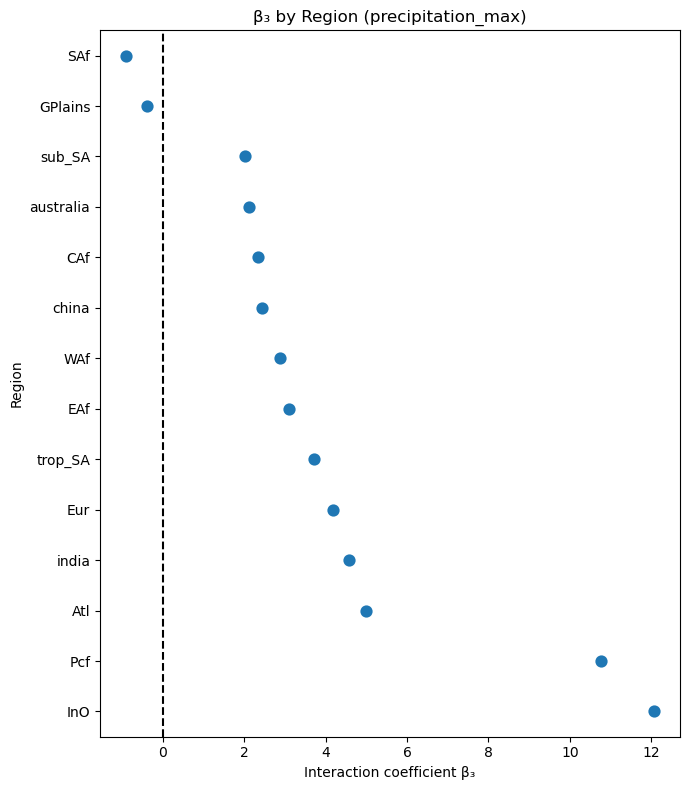

In [163]:
plt.figure(figsize=(7, 8))

sns.pointplot(
    data=beta3_df,
    x="beta3",
    y="region",
    join=False
)

plt.axvline(0, color='k', linestyle='--')
plt.xlabel("Interaction coefficient β₃")
plt.ylabel("Region")
plt.title(f"β₃ by Region ({response_var})")

plt.tight_layout()
plt.show()


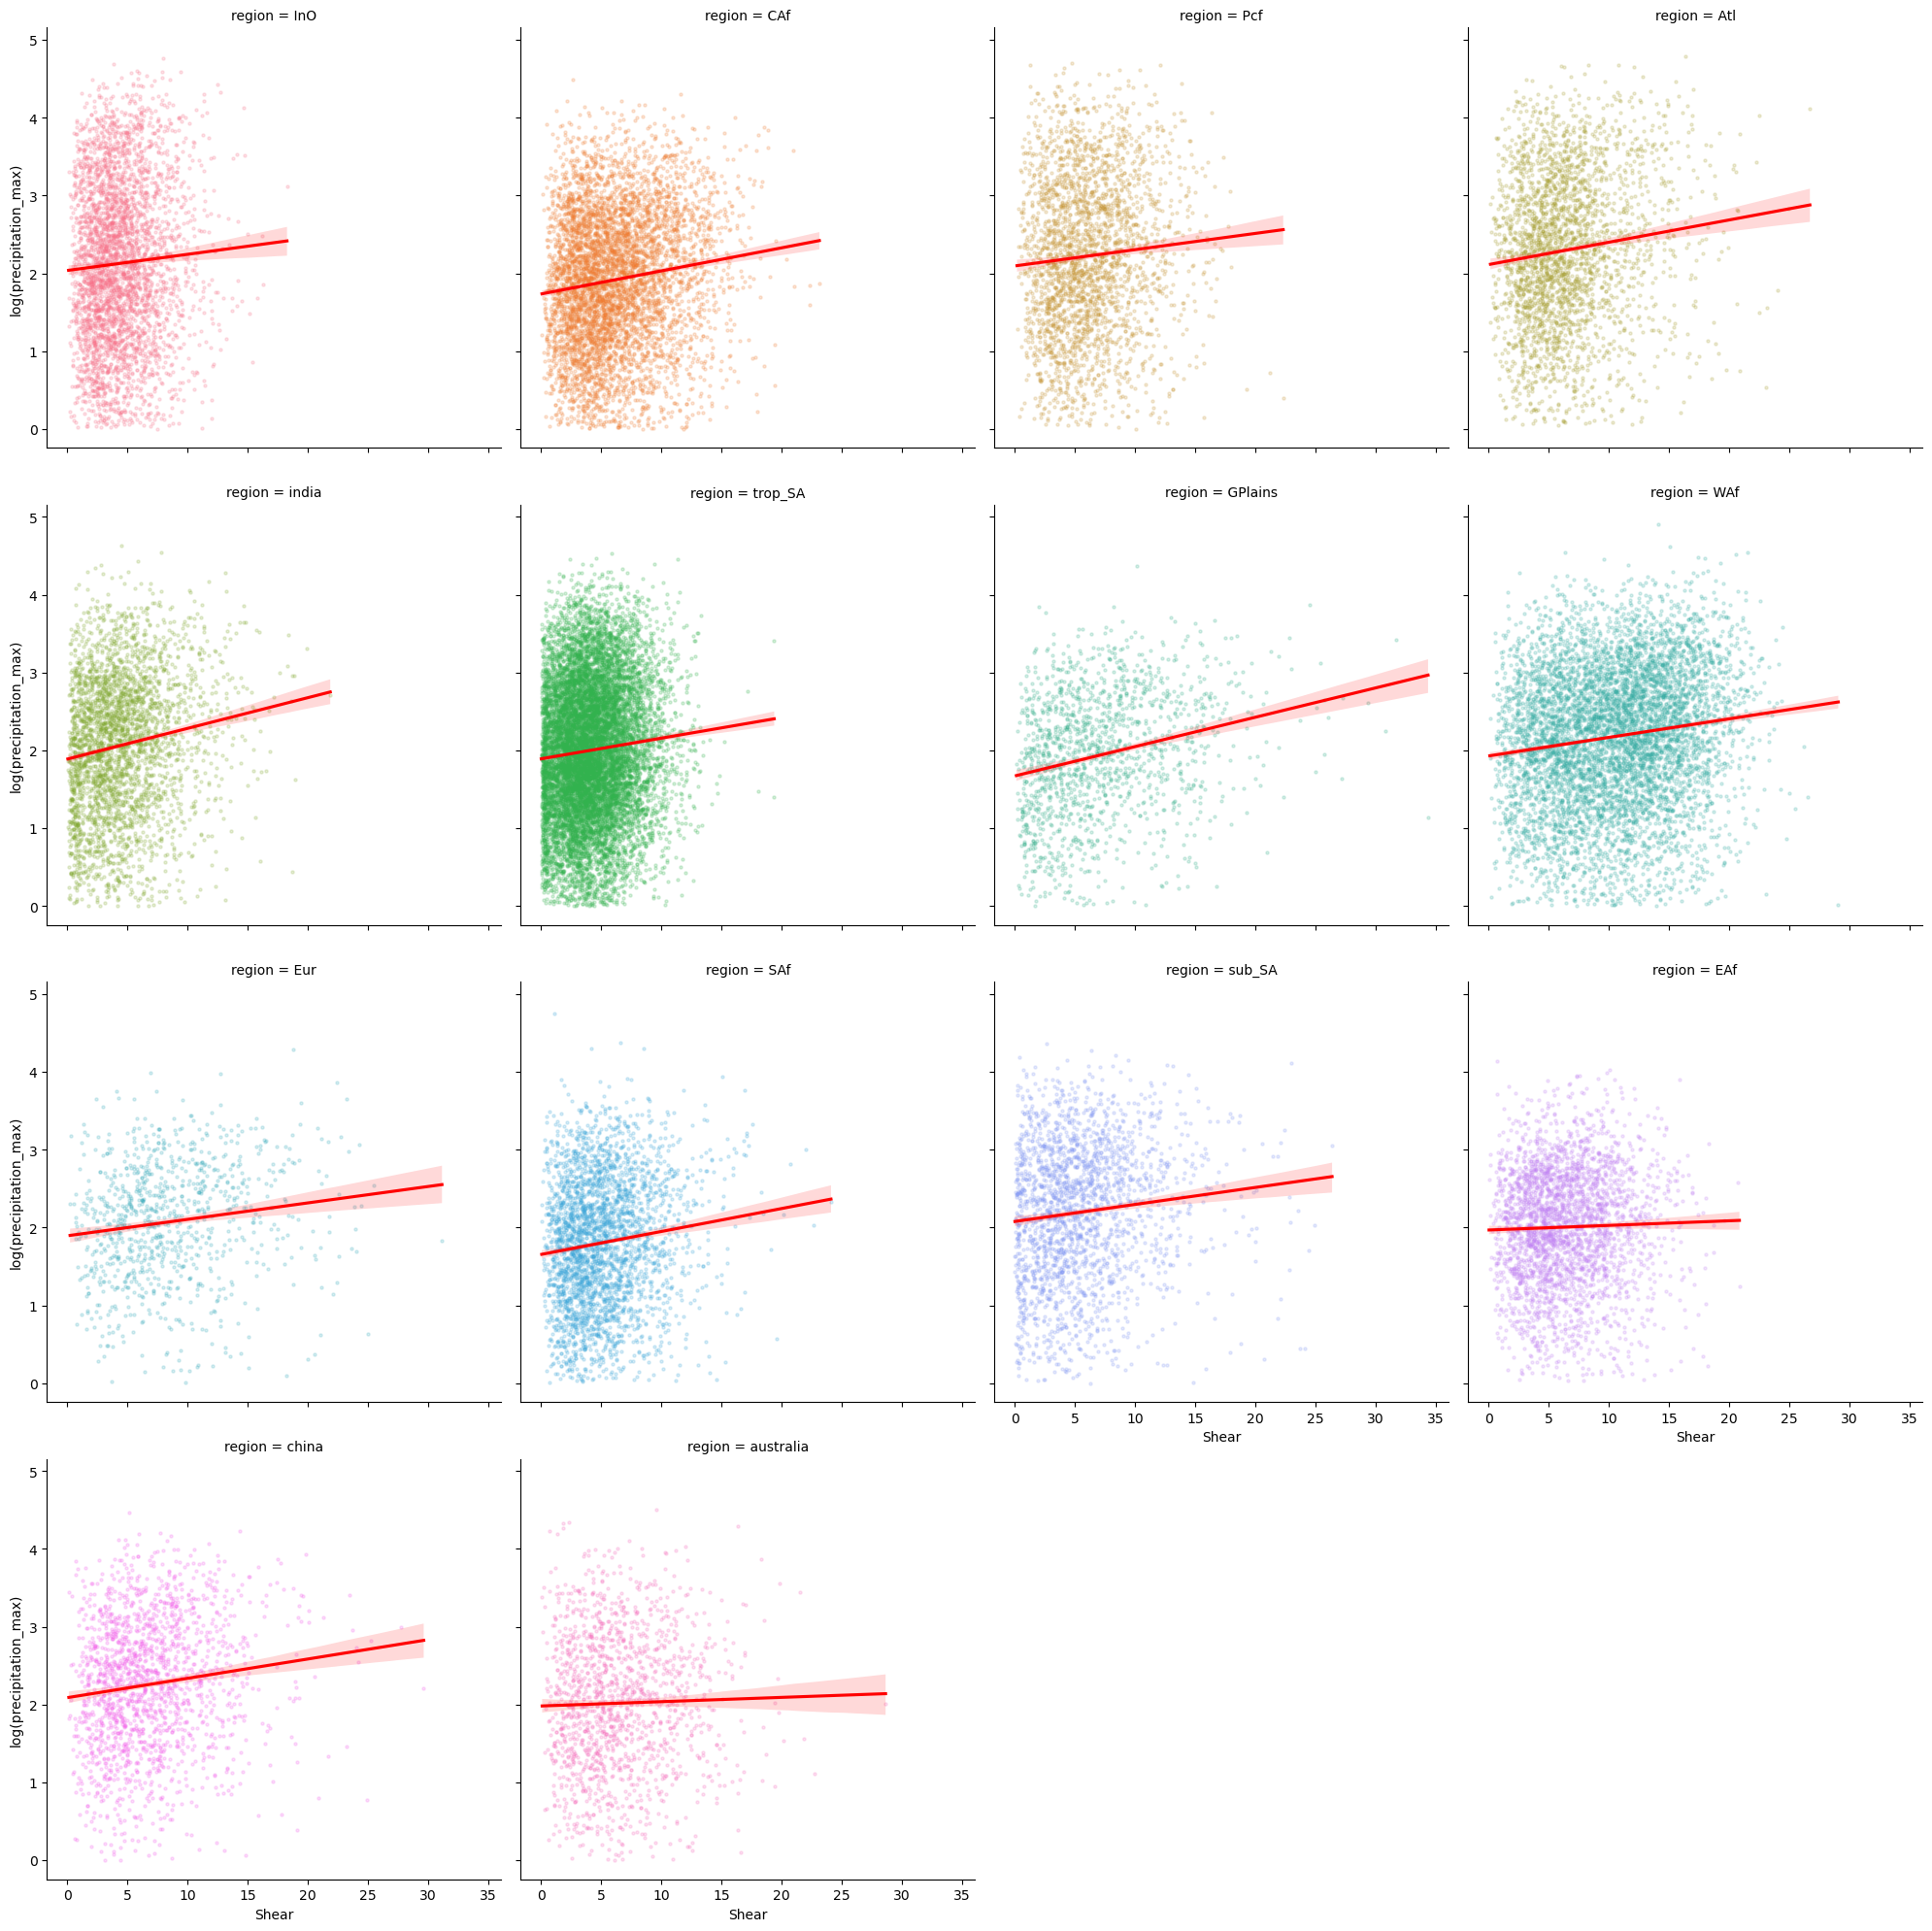

In [164]:

# Use sample if dataset is large
df_plot = df_env.sample(min(len(df_env), 50000), random_state=42)

g = sns.lmplot(
    data=df_plot,
    x="shear100_650",
    y="y",
    hue="region",
    col="region",
    col_wrap=4,
    scatter_kws={"alpha": 0.2, "s": 5},
    line_kws={"color": "red"},
    ci=95
)

g.set_axis_labels("Shear", f"log({response_var})")

plt.show()


<Figure size 800x600 with 0 Axes>

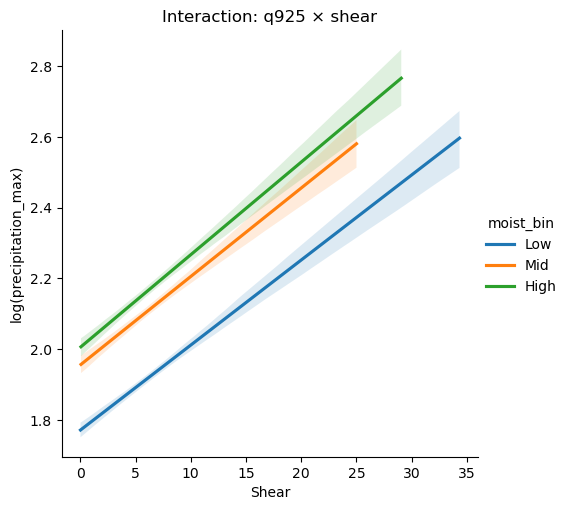

In [165]:

# Create TCW terciles for visualization only
df_plot["moist_bin"] = pd.qcut(df_plot[moisture_var], 3, labels=["Low", "Mid", "High"])

plt.figure(figsize=(8, 6))

sns.lmplot(
    data=df_plot,
    x="shear100_650",
    y="y",
    hue="moist_bin",
    scatter=False,
    ci=95
)

plt.title(f"Interaction: {moisture_var} × shear")
plt.xlabel("Shear")
plt.ylabel(f"log({response_var})")

plt.show()


In [166]:

# Fixed effect
beta3_fixed = result.params[f"{moisture_var}_c:shear100_650"]

# Variance of fixed effect
cov_fe = result.cov_params()
var_fixed = cov_fe.loc[
    f"{moisture_var}_c:shear100_650",
    f"{moisture_var}_c:shear100_650"
]

region_data = []

for region, effects in result.random_effects.items():
    re_val = effects.get(f"{moisture_var}_c:shear100_650", 0.0)

    beta3 = beta3_fixed + re_val

    # Random variance (from covariance matrix)
    var_random = result.cov_re.iloc[-1, -1]  # interaction term assumed last

    se = np.sqrt(var_fixed + var_random)

    ci_low = beta3 - 1.96 * se
    ci_high = beta3 + 1.96 * se

    region_data.append([region, beta3, ci_low, ci_high])

beta3_df = pd.DataFrame(
    region_data, columns=["region", "beta3", "ci_low", "ci_high"]
).sort_values("beta3")


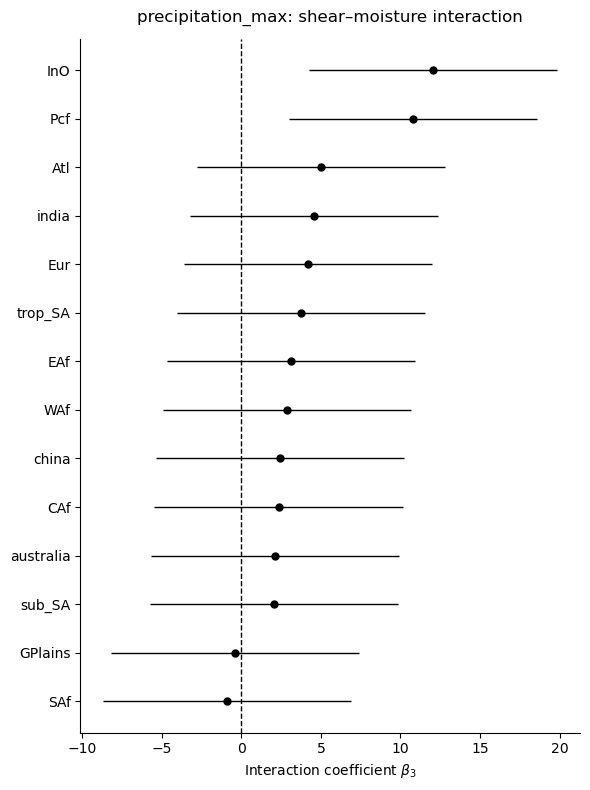

In [167]:

plt.figure(figsize=(6, 8))

plt.hlines(
    y=beta3_df["region"],
    xmin=beta3_df["ci_low"],
    xmax=beta3_df["ci_high"],
    color="black",
    linewidth=1
)

plt.plot(
    beta3_df["beta3"],
    beta3_df["region"],
    "o",
    color="black",
    markersize=5
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel(r"Interaction coefficient $\beta_3$")
plt.ylabel("")

plt.title(f"{response_var}: shear–moisture interaction", pad=12)

# Clean style
sns.despine()
plt.grid(False)

plt.tight_layout()
plt.show()
